# Elevator RL Simulation Demo

Run the trained PPO model, record a smooth video, and play it inline in the notebook.

In [1]:
import sys
sys.path.insert(0, '.')
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"  # prevent pygame from needing a display

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import imageio
from IPython.display import Video, display
from sb3_contrib import MaskablePPO
from elevator_env import ElevatorEnv

%matplotlib inline

## Load the trained model and create the environment

In [2]:
model = MaskablePPO.load('modell/ppo_elevator_episode_1318.zip')

# spawn_intervall=1800 makes guests arrive 4x faster than default (7200)
# so you see meaningful elevator decisions sooner
env = ElevatorEnv(
    render_mode=None,
    num_elevators=3,
    num_floors=10,
    max_passengers=5,
    max_guests=30,
    spawn_intervall=1800,
)
print(f'Environment ready: {env.num_elevators} elevators, {env.num_floors} floors, {env.max_guests} guests')
print(f'Guests arrive ~{env.max_guests / env.spawn_intervall * 3600:.0f}/hour')

Environment ready: 3 elevators, 10 floors, 30 guests
Guests arrive ~60/hour


## Helper: extract single-elevator observation for the trained model

In [3]:
def get_single_elevator_obs(full_obs, elevator_idx, num_floors):
    elev_size = 2 + num_floors
    start = elevator_idx * elev_size
    elev_obs = list(full_obs[start:start + elev_size])
    for _ in range(2):
        elev_obs.extend([0] * elev_size)
    waiting_start = len(full_obs) - num_floors
    elev_obs.extend(full_obs[waiting_start:])
    return np.array(elev_obs, dtype=np.int32)

## Render a frame to an RGB array (for video recording)

In [4]:
def make_renderer(env):
    """Create a reusable renderer that updates artists in place (much faster than recreating figures)."""
    num_floors = env.num_floors
    num_elevators = env.num_elevators

    fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=80)
    ax.set_xlim(-0.5, num_elevators + 1.5)
    ax.set_ylim(-0.5, num_floors - 0.5)
    ax.set_yticks(range(num_floors))
    ax.set_yticklabels([f'F{i}' for i in range(num_floors)])
    ax.set_xticks(range(num_elevators))
    ax.set_xticklabels([f'E{i}' for i in range(num_elevators)])
    for f in range(num_floors + 1):
        ax.axhline(y=f - 0.5, color='#ddd', linewidth=0.5)

    elev_rects = []
    elev_texts = []
    for idx in range(num_elevators):
        rect = FancyBboxPatch(
            (idx - 0.35, -0.35), 0.7, 0.7,
            boxstyle='round,pad=0.05', facecolor='#2196F3', edgecolor='black', linewidth=1.5,
        )
        ax.add_patch(rect)
        elev_rects.append(rect)
        txt = ax.text(idx, 0, '0', ha='center', va='center', fontsize=16, fontweight='bold', color='white')
        elev_texts.append(txt)

    wait_texts = []
    for floor in range(num_floors):
        txt = ax.text(num_elevators + 0.3, floor, '', ha='left', va='center', fontsize=10, color='#d32f2f')
        wait_texts.append(txt)

    title_text = ax.set_title('', fontsize=11, fontweight='bold')
    fig.tight_layout()

    def render():
        for idx, elev in enumerate(env.elevators):
            color = '#4CAF50' if elev.door_open else '#2196F3'
            elev_rects[idx].remove()
            rect = FancyBboxPatch(
                (idx - 0.35, elev.current_floor - 0.35), 0.7, 0.7,
                boxstyle='round,pad=0.05', facecolor=color, edgecolor='black', linewidth=1.5,
            )
            ax.add_patch(rect)
            elev_rects[idx] = rect
            elev_texts[idx].set_position((idx, elev.current_floor))
            elev_texts[idx].set_text(str(len(elev.passengers)))

        for floor in range(num_floors):
            count = sum(1 for g in env.waiting_guests if g.current_floor == floor)
            wait_texts[floor].set_text(f'{count} waiting' if count > 0 else '')

        sim_seconds = env.episode_steps
        hours = 8 + sim_seconds // 3600
        minutes = (sim_seconds % 3600) // 60
        title_text.set_text(
            f'Time {hours:02}:{minutes:02}  |  '
            f'Waiting: {len(env.waiting_guests)}  |  '
            f'Riding: {len(env.guests_in_elevator)}  |  '
            f'Done: {env.guests_left_building}/{env.max_guests}'
        )

        fig.canvas.draw()
        buf = fig.canvas.buffer_rgba()
        return np.asarray(buf)[:, :, :3].copy()

    def close():
        plt.close(fig)

    return render, close

## Record the simulation as a video

Captures a frame every 20 sim-steps, then encodes as mp4 at 15fps for smooth playback.

In [5]:
obs, info = env.reset()
terminated = False
truncated = False
step_count = 0
capture_every = 20
frames = []

render_frame, close_renderer = make_renderer(env)

print("Recording simulation...")
while not terminated and not truncated:
    action_masks = info['action_mask']
    actions = []
    for i in range(env.num_elevators):
        elev_obs = get_single_elevator_obs(obs, i, env.num_floors)
        action, _ = model.predict(elev_obs, action_masks=action_masks[i], deterministic=True)
        actions.append(int(action[0]))

    obs, reward, terminated, truncated, info = env.step(actions)
    step_count += 1

    if step_count % capture_every == 0:
        frames.append(render_frame())

close_renderer()
print(f"Done! Recorded {len(frames)} frames over {step_count} steps.")
print(f"Guests processed: {env.guests_left_building}/{env.max_guests}")

# Save as mp4
video_path = "elevator_sim.mp4"
imageio.mimwrite(video_path, frames, fps=15, quality=8)
print(f"Video saved: {video_path}")

Recording simulation...
Done! Recorded 1753 frames over 35076 steps.
Guests processed: 30/30
Video saved: elevator_sim.mp4


## Play the video

In [6]:
display(Video(video_path, embed=True, width=640))

## Results

In [7]:
import pandas as pd

df = pd.DataFrame(env.logs)
wait_df = df[df['mode'] == 'elevator_waiting']
drive_df = df[df['mode'] == 'elevator_drive']

print(f'Total log entries: {len(df)}')
print(f'Avg wait time:  {wait_df["wait_time"].mean():.1f}s')
print(f'Avg ride time:  {drive_df["travel_time"].mean():.1f}s')
print(f'Avg total time: {(drive_df["wait_time"] + drive_df["travel_time"]).mean():.1f}s')
print(f'Total reward:   {env.total_reward:.0f}')

Total log entries: 1086
Avg wait time:  18.6s
Avg ride time:  28.2s
Avg total time: 46.8s
Total reward:   14478


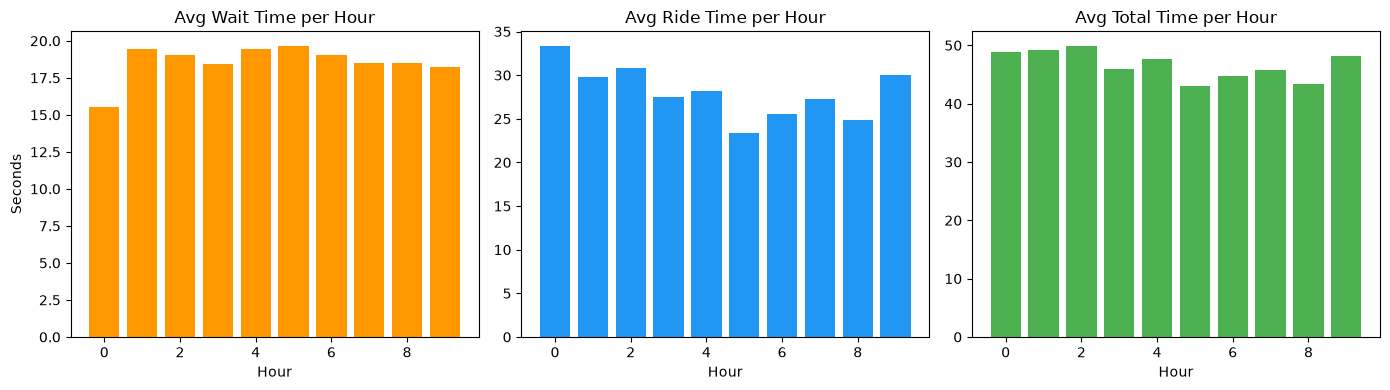

In [8]:
if not drive_df.empty:
    fig2, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    drive_df = drive_df.copy()
    drive_df['hour'] = (drive_df['time'] // 3600).astype(int)
    drive_df['total_time'] = drive_df['wait_time'] + drive_df['travel_time']
    
    hourly = drive_df.groupby('hour').agg(
        avg_wait=('wait_time', 'mean'),
        avg_ride=('travel_time', 'mean'),
        avg_total=('total_time', 'mean'),
    ).reset_index()
    
    axes[0].bar(hourly['hour'], hourly['avg_wait'], color='#FF9800')
    axes[0].set_title('Avg Wait Time per Hour')
    axes[0].set_ylabel('Seconds')
    
    axes[1].bar(hourly['hour'], hourly['avg_ride'], color='#2196F3')
    axes[1].set_title('Avg Ride Time per Hour')
    
    axes[2].bar(hourly['hour'], hourly['avg_total'], color='#4CAF50')
    axes[2].set_title('Avg Total Time per Hour')
    
    for a in axes:
        a.set_xlabel('Hour')
    
    plt.tight_layout()
    plt.show()